<a href="https://colab.research.google.com/github/xinxinhuang/Npw_Group1_DataAnalyticsProject/blob/main/npw_data_analytics_project_group_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Analytics Project Activity: Group 1.
<strong>Content </strong><br>
1. Dataset overview<br>
2. Data Wrangling<br>
3. Exploratory Data Analysis<br>
4. Interactive Dashboard <br>
5. Key Takeaways & Project ResourcesKey<br>
<strong>Link: </strong>https://www.kaggle.com/datasets/harshitsama/us-grocery-and-gas-prices-2015-2026

<strong> Dataset Overview</strong><br>
<strong>1. Dataset Chosen: </strong>US Grocery and Gas Prices (2015 – 2026), sourced from Kaggle.com<br>
<strong>Original Source:</strong> U.S. Bureau of Labor Statistics (BLS), Average Price Data (AP) programme<br>
This dataset tracks the monthly average retail price items purchased by American households, including such as eggs, milk, bread, beef, chicken, coffee, fresh produce, and gasoline. It covers roughly an eleven-year window, from 2015 through 2026.<br>
<strong>2. About the Data Source</strong>
The BLS Average Price Data programme is a by-product of the Consumer Price Index (CPI) survey. Every month, BLS data collectors record the prices of specific goods at thousands of retail outlets across U.S. urban areas. Those observations are averaged to produce a U.S. city average" price for each item.

<strong>Key characteristics:</strong><br>
•	Frequency: monthly<br>
•	Units: prices are in U.S. dollars per standard<br>
•	Coverage: which is the population the CPI represents<br>

 <strong>3. Why This Dataset?</strong><br>

The 2015–2026 period includes several major economic events that visibly affected household prices:a relatively stable, low-inflation baseline, pandemic, supply-chain disruption and ,  gasoline price spike following Russia's invasion of Ukraine ,repeated egg price surges linked to avian flu outbreaks
This gives us a real-world dataset with clear "before, during, and after" periods to analyse.</strong><br>

<strong>4. Project Objectives</strong><br>
•	Clean and prepare the data (handle missing months, standardise dates and item names, check units).<br>
•	Explore long-term price trends for individual items and item categories.<br>
•	Measure price change over time (percentage change, year-over-year growth, volatility).<br>
•	Compare prices<br>
•	Examine whether gasoline prices move together with grocery prices.<br>
•	Communicate findings through clear visualisations and a short summary.<br>

<strong>5. Dataset Structure:</strong><br>
Fill in after loading the data: file name(s), number of rows and columns, column names and data types, date range, and number of missing values.<br>
<strong>6. Tools used:</strong><br>
Python (pandas, NumPy, Matplotlib,Seaborn) in a google colab.




# Step 1: Loading the Data

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # statistical visualization library
import matplotlib.pyplot as plt # plotting library
import os # Low level OS operations such as inspecting paths, checking file existence and renaming individual items
import shutil # file management operations, copy, move dir, delete dir.
import matplotlib.patches as patches

!pip install -q kagglehub
import kagglehub # library for kagglehub

# Download the dataset from kaggle directly instead of uploading each time.
print("Loading dataset from kaggle..")
path = kagglehub.dataset_download("harshitsama/us-grocery-and-gas-prices-2015-2026")
print("Dataset loaded to:", path)

source_csv = os.path.join(path, "us_average_prices_wide.csv")
destination_csv = "us_average_prices_wide.csv"
shutil.copy(source_csv, destination_csv)
df_wide = pd.read_csv(destination_csv)
print(" Successsfully loaded df_wide with shape:", df_wide.shape)

Loading dataset from kaggle..


100%|██████████| 98.5k/98.5k [00:00<00:00, 508kB/s]


Extracting files...
Dataset loaded to: /root/.cache/kagglehub/datasets/harshitsama/us-grocery-and-gas-prices-2015-2026/versions/2
 Successsfully loaded df_wide with shape: (139, 75)


In [ ]:
df_wide.head()

,date,All Ham (Excluding Canned Ham and Luncheon Slices),All Other Pork (Excluding Canned Ham and Luncheon Slices),All Pork Chops,All Uncooked Beef Roasts,All Uncooked Beef Steaks,All Uncooked Other Beef (Excluding Veal),All soft drinks,"All soft drinks, 12 pk, 12 oz., cans",All uncooked ground beef,...,"Steak, round, graded and ungraded, excluding USDA Prime and Choice","Steak, sirloin, USDA Choice, boneless","Strawberries, dry pint","Sugar, white, 33-80 oz. pkg","Sugar, white, all sizes","Tomatoes, field grown","Turkey, frozen, whole",Utility (piped) gas,"Wine, red and white table, all sizes, any origin",Yogurt
0,2015-01-01,3.211,2.991,3.988,5.838,7.530,4.734,NaN,NaN,4.675,...,6.161,8.080,2.454,0.626,0.644,2.089,1.445,1.036,12.912,NaN
1,2015-02-01,3.221,2.928,3.962,5.844,7.569,4.684,NaN,NaN,4.708,...,6.024,8.194,2.090,0.649,0.659,1.849,1.480,1.007,12.370,NaN
2,2015-03-01,3.176,2.904,3.867,5.872,7.661,4.709,NaN,NaN,4.677,...,6.085,8.372,1.664,0.653,0.660,1.819,1.503,0.985,12.370,NaN
3,2015-04-01,2.971,2.836,3.813,5.864,7.684,4.702,NaN,NaN,4.681,...,6.155,8.329,1.852,0.662,0.663,1.847,1.487,0.947,12.335,NaN
4,2015-05-01,3.045,2.804,3.786,5.915,7.773,4.590,NaN,NaN,4.653,...,6.013,8.816,2.087,0.648,0.660,1.740,1.527,0.930,12.044,NaN


# Step 2: Data Wrangling

What do the dtypes look like? How much missing values are we dealing with?

In [ ]:
df_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 75 columns):
 #   Column                                                              Non-Null Count  Dtype  
---  ------                                                              --------------  -----  
 0   date                                                                139 non-null    object 
 1   All Ham (Excluding Canned Ham and Luncheon Slices)                  132 non-null    float64
 2   All Other Pork (Excluding Canned Ham and Luncheon Slices)           137 non-null    float64
 3   All Pork Chops                                                      138 non-null    float64
 4   All Uncooked Beef Roasts                                            138 non-null    float64
 5   All Uncooked Beef Steaks                                            138 non-null    float64
 6   All Uncooked Other Beef (Excluding Veal)                            137 non-null    float64
 7   All soft drinks  

In [ ]:
print(f"Dataframe shape: {df_wide.shape}")
print(f"{df_wide.shape[0]} rows, {df_wide.shape[1]} columns.")
df_wide.dtypes.value_counts()

# remaining 74 columns are all in the approriate type float64.

Dataframe shape: (139, 75)
139 rows, 75 columns.


,count
float64,74
object,1


## 2.1: Fix Data Types.

In [ ]:
# only date column needs data type changes.
df_cleaning = df_wide.copy()
df_cleaning['date'] = pd.to_datetime(df_cleaning['date'])
df_cleaning.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 75 columns):
 #   Column                                                              Non-Null Count  Dtype         
---  ------                                                              --------------  -----         
 0   date                                                                139 non-null    datetime64[ns]
 1   All Ham (Excluding Canned Ham and Luncheon Slices)                  132 non-null    float64       
 2   All Other Pork (Excluding Canned Ham and Luncheon Slices)           137 non-null    float64       
 3   All Pork Chops                                                      138 non-null    float64       
 4   All Uncooked Beef Roasts                                            138 non-null    float64       
 5   All Uncooked Beef Steaks                                            138 non-null    float64       
 6   All Uncooked Other Beef (Excluding Veal)                  

## 2.2: Remove duplicate values.

In [ ]:
print(f"Dataframe contains {df_cleaning.duplicated().sum()} duplicate rows and {df_cleaning.T.duplicated().sum()} duplicate columns.")
print(f"THere are {df_cleaning.duplicated('date').sum()} duplicate dates in the date column.")


Dataframe contains 0 duplicate rows and 0 duplicate columns.
THere are 0 duplicate dates in the date column.


## 2.3: Handle Missing Values.
### 2.31: Visualizing how many missing values we have and where they are in the data.



Text(4, 20, '??')

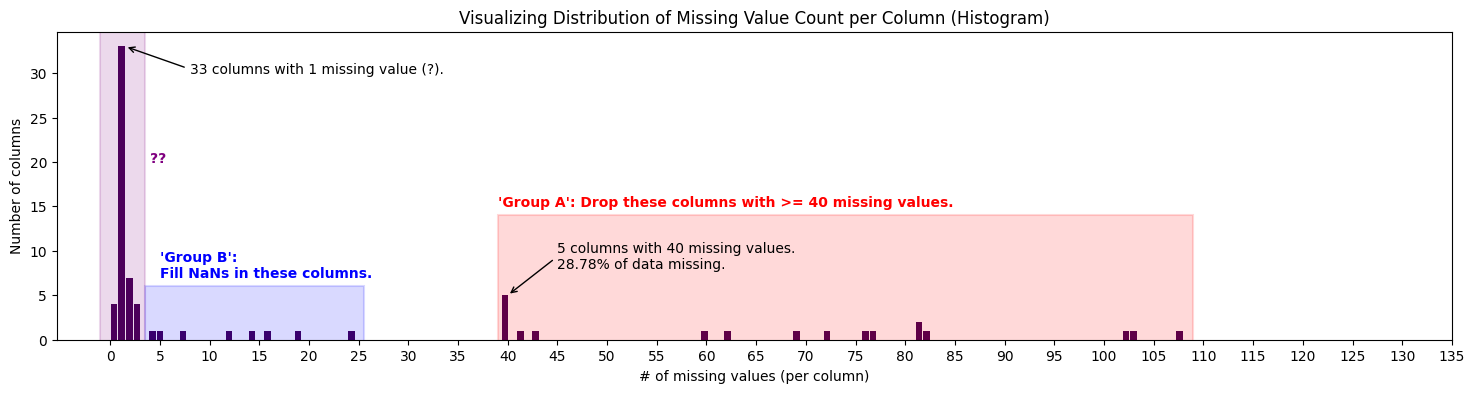

In [ ]:
most_freq_num_of_nan = df_wide.isna().sum().value_counts().reset_index().iloc[0, 0]
freq = df_wide.isna().sum().value_counts().max()

#print(df_wide.isna().sum().value_counts())
#print(df_wide.isna().sum().value_counts().sort_index())

df_wide.isna().sum().plot(kind = 'hist',
                          xlabel = '# of missing values (per column)',
                          ylabel = 'Number of columns',
                          title='Visualizing Distribution of Missing Value Count per Column (Histogram)',
                          bins = 140,
                          xticks = np.arange(0, 140, 5), colormap = 'viridis',
                          rwidth=0.9,
                          figsize = (18, 4))

plt.annotate(
    f'{freq} columns with {most_freq_num_of_nan} missing value (?).',
    xy=(1.5, 33),
    xytext=(8, 30),
    arrowprops=dict(
        facecolor='black',
        arrowstyle = '->',
        relpos=(0, 0.5)
    )
)

plt.annotate(
    f'5 columns with 40 missing values.\n{round(40/139*100, 2)}% of data missing.',
    xy=(40, 5),
    xytext=(45, 8),
    arrowprops=dict(
        facecolor='black',
        arrowstyle = '->',
        relpos=(0, 0.5)
    )
)

# box for >40 nans
rect = patches.Rectangle(
    xy=(39, -2),  # bottom left
    width=70,
    height=16,
    linewidth=1.5,
    edgecolor='red',
    facecolor='red',
    alpha=0.15
)
plt.gca().add_patch(rect)
plt.text(39, 15, "'Group A': Drop these columns with >= 40 missing values.", color='red', fontweight='bold')

# box for >=10 and <40 nans
rect = patches.Rectangle(
    xy=(3.5, -2),
    width=22,
    height=8,
    linewidth=1.5,
    alpha=0.15,
    edgecolor='blue',
    facecolor='blue',
)
plt.gca().add_patch(rect)
plt.text(5,7, "'Group B':\nFill NaNs in these columns.", color='blue', fontweight='bold')

# box for cluster of columns with low count mising values.
rect = patches.Rectangle(
    xy=(-1, -2),  # bottom left
    width=4.5,
    height=38,
    linewidth=1.5,
    alpha=0.15,
    edgecolor='purple',
    facecolor='purple',
)
plt.gca().add_patch(rect)
plt.text(4, 20, '??', color='purple', fontweight='bold')


<Axes: title={'center': 'Plot to help visualize missing values location in data (Date vs Price)'}, xlabel='Date', ylabel='Price (USD)'>

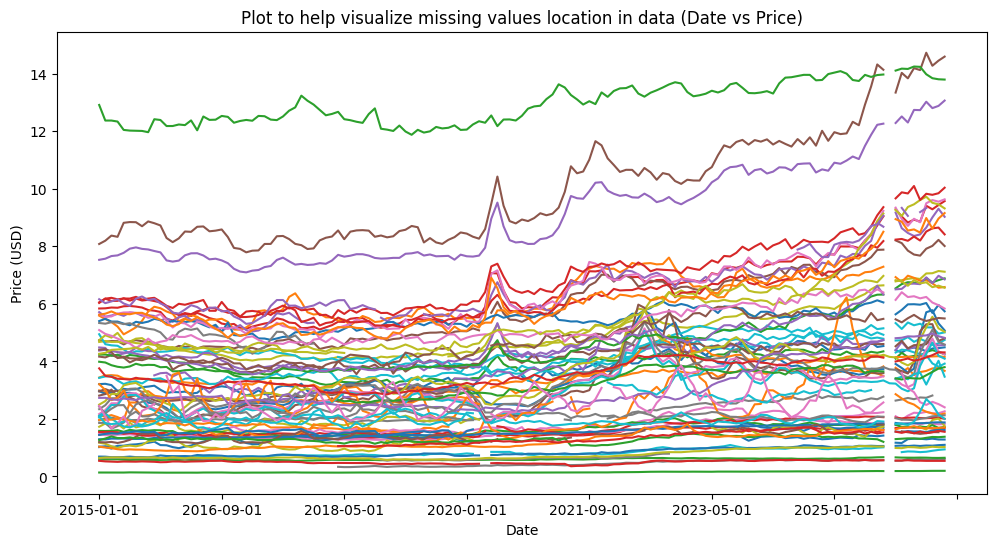

In [ ]:
df_wide.set_index('date').plot(legend = False, figsize = (12, 6), title="Plot to help visualize missing values location in data (Date vs Price)",
                               xlabel = 'Date',
                               ylabel = 'Price (USD)')


What month corresponds to the gap in the data?

In [ ]:
# find the number of missing values per row (each row corresponds to a month)
gap_df = df_cleaning.isna().T.sum().sort_values(ascending = False).reset_index()
gap_df.columns = (['row index', 'total na values for row'])
gap_df.head()

,row index,total na values for row
0,129,71
1,63,25
2,64,17
3,66,15
4,68,15


In [ ]:
# 71 missing values in row #129, which is...
print(f"Row 129:")
print(df_cleaning.iloc[129])
print(f"---\nDate of row 129:")
print(df_cleaning.iloc[129][:1])

Row 129:
date                                                         2025-10-01 00:00:00
All Ham (Excluding Canned Ham and Luncheon Slices)                           NaN
All Other Pork (Excluding Canned Ham and Luncheon Slices)                    NaN
All Pork Chops                                                               NaN
All Uncooked Beef Roasts                                                     NaN
                                                                    ...         
Tomatoes, field grown                                                        NaN
Turkey, frozen, whole                                                        NaN
Utility (piped) gas                                                          NaN
Wine, red and white table, all sizes, any origin                             NaN
Yogurt                                                                       NaN
Name: 129, Length: 75, dtype: object
---
Date of row 129:
date    2025-10-01 00:00:00
Name: 129, dty

Reason for the missing values on October of 2025: US Federal Government Shutdown.

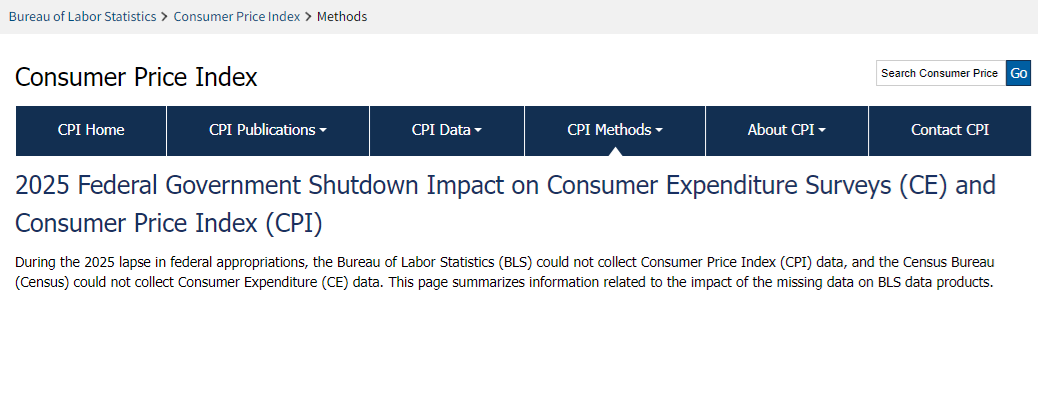

Source: https://www.bls.gov/cpi/additional-resources/2025-federal-government-shutdown-impact-cpi.htm

### 2.31: Dealing with the missing values - Part 1
Drop Group A columns (>= 40 missing values).

In [ ]:
# grocery items with >= 40 missing values will be dropped.
num_of_na = df_wide.isna().sum()
to_be_dropped = num_of_na[num_of_na >= 40].sort_values().index.tolist()

print(f"Dropping {len(to_be_dropped)} columns:\n")
print(*to_be_dropped, sep = '\n')
print("---")

df_cleaning_2 = df_cleaning.drop(to_be_dropped, axis = 1)
print(f"Original df shapee: {df_wide.shape}")
print(f"Cleaning df shape: {df_cleaning_2.shape}")


Dropping 19 columns:

All soft drinks
All soft drinks, 12 pk, 12 oz., cans
Butter, stick
Milk, fresh, low-fat, reduced fat, skim
Yogurt
Lettuce, iceberg
Grapefruit
Frankfurters, all meat or all beef
Grapes, Thompson Seedless
Sugar, white, 33-80 oz. pkg
Steak, round, graded and ungraded, excluding USDA Prime and Choice
Broccoli
Turkey, frozen, whole
Peppers, sweet
Margarine, soft, tubs
Bologna, all beef or mixed
Corn, canned, any style, all sizes
Chuck roast, graded and ungraded, excluding USDA Prime and Choice
Pears, Anjou
---
Original df shapee: (139, 75)
Cleaning df shape: (139, 56)


### 2.32: Dealing with missing values - Part 2.
Group B Columns: >= 4 and < 40 missing values.<br>
Try to fill these values.

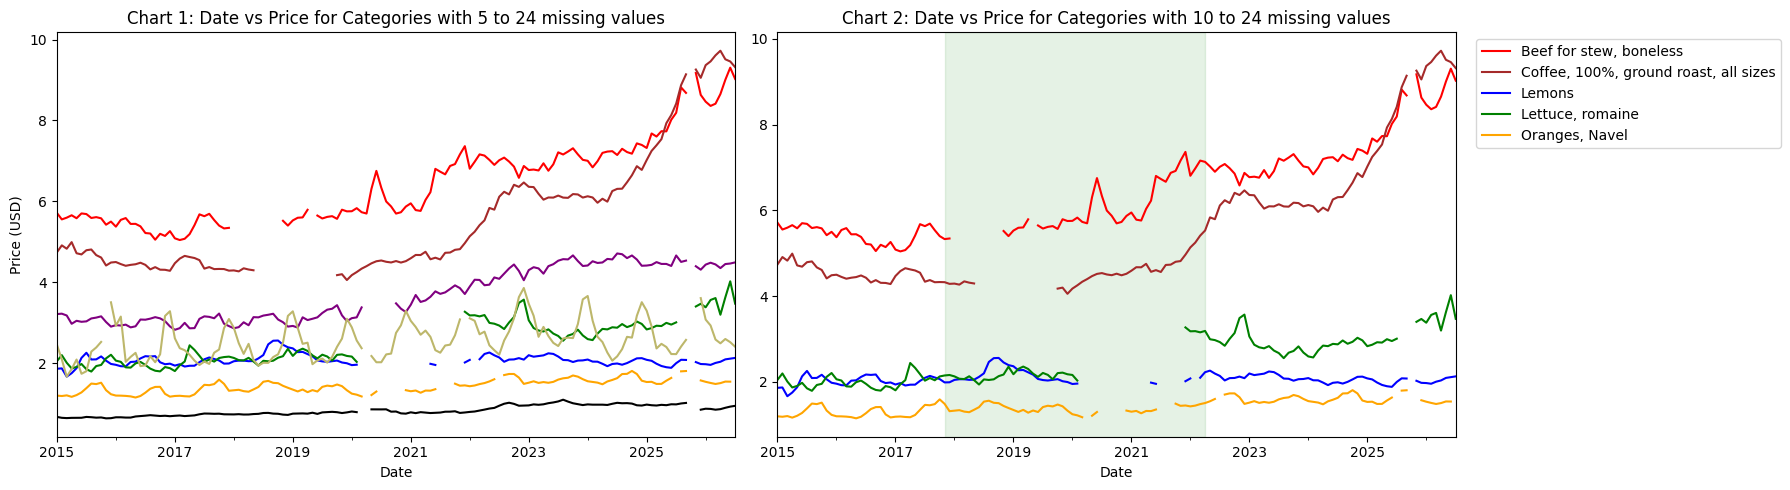

In [ ]:
category_colors = {
    'Potatoes, white': 'black',
    'Strawberries, dry pint': 'darkkhaki',
    'All Ham (Excluding Canned Ham and Luncheon Slices)': 'purple',
    'Beef for stew, boneless': 'red',
    'Oranges, Navel': 'orange',
    'Coffee, 100%, ground roast, all sizes': 'brown',
    'Lemons': 'blue',
    'Lettuce, romaine': 'green'
}

group_b = num_of_na[(num_of_na < 40) & (num_of_na >= 4)].index.tolist()
group_b.append('date')
#print(f"Remaining {df_cleaning_2[group_b].isna().sum().sort_values()}")

colors_1 = [category_colors.get(cat, 'pink') for cat in df_cleaning_2[group_b].columns]

fig, axes = plt.subplots(1, 2, figsize = (18, 5))
df_cleaning_2[group_b].set_index('date').plot(ax = axes[0],
                                              title = "Chart 1: Date vs Price for Categories with 5 to 24 missing values",
                                              legend = False,
                                              ylabel = 'Price (USD)',
                                              xlabel='Date',
                                              color=colors_1)

group_b = num_of_na[(num_of_na < 40) & (num_of_na >= 10)].index.tolist()
group_b.append('date')

colors_2 = [category_colors.get(cat, 'pink') for cat in df_cleaning_2[group_b].columns]

df_cleaning_2[group_b].set_index('date').plot(ax = axes[1],
                                              title = "Chart 2: Date vs Price for Categories with 10 to 24 missing values",
                                              legend = True,
                                              xlabel='Date',
                                              color = colors_2)
axes[1].legend(bbox_to_anchor=(1.02, 1))

axes[1].axvspan('2017-11-01', '2022-04-01', color='green', alpha=0.10)

plt.tight_layout()

Two approaches to filling in missing values:<br>
#### 2.32.1: Method 1: Linear Interpolation
draw a straight line to fill gap between known values.<br>

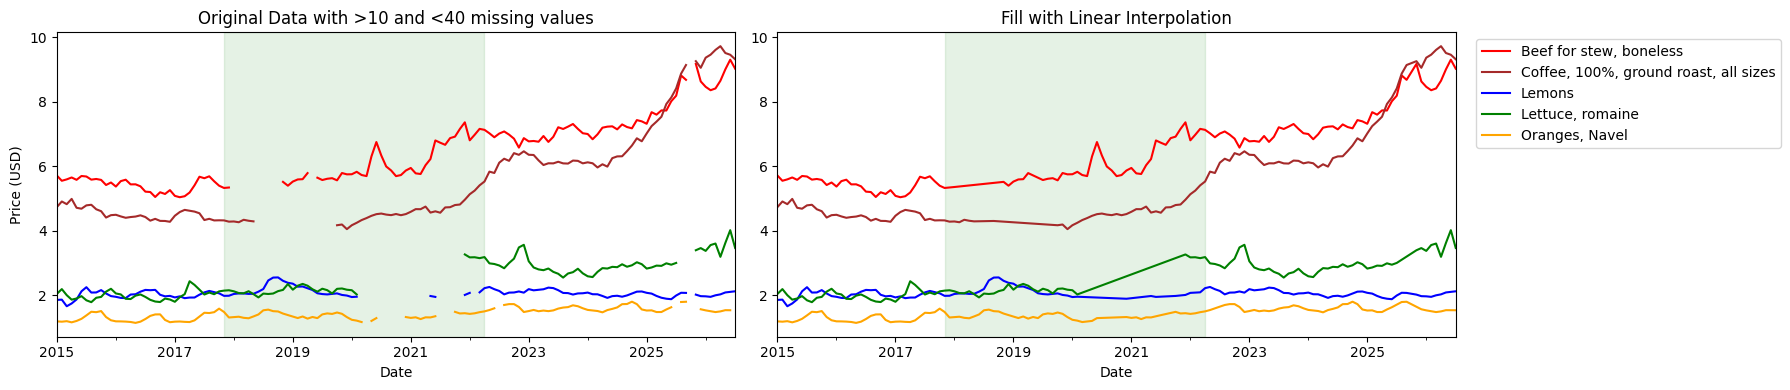

In [ ]:
group_b = num_of_na[(num_of_na < 40) & (num_of_na >= 10)].index.tolist()
group_b.append('date')

# Approach 1: Use linear interpretation.
# use panda's interpolation to draw a straight line connecting the two points
df_method_1 = df_cleaning_2.interpolate()

fig, axes = plt.subplots(1, 2, figsize=(18, 4))

df_cleaning_2[group_b].set_index('date').plot(ax = axes[0], legend = False, title="Original Data with >10 and <40 missing values", ylabel = 'Price (USD)', xlabel = 'Date', color = colors_2)
df_method_1[group_b].set_index('date').plot(ax = axes[1], legend = False, title="Fill with Linear Interpolation", xlabel = 'Date', color = colors_2)
#df_method_1.info()

axes[0].axvspan('2017-11-01', '2022-04-01', color='green', alpha=0.10)
axes[1].axvspan('2017-11-01', '2022-04-01', color='green', alpha=0.10)
axes[1].legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
#plt.gca().add_patch(rect)
#plt.text(4, 20, '??', color='purple', fontweight='bold')

plt.show()


#### 2.32.2: Method 2 - Estimate a value using the mean historic month to month pirce difference percentage.

Step 1: Find % change in price between two consecutive months. Eg:<br>
<br>
$$ \% \text{ Change in Price May 2015} = \text{ } \frac {\text{Price in May 2015} - \text{Price in April 2015 }}{\text{Price in April 2015}}$$
<br>
Step 2: Find the Mean % change in price of a month using data from 2015 to 2026, Eg for May:<br>
<br>
$$ \text{Mean }\% \text{ Change in Price May} = \text{ }\frac{\text{ }\% \text{ Change in May 2015} + \dots + \% \text{ Change in May 2025 }}{\text{Total monthly data available for May}} $$
<br>
Then we use the mean to predict values and fill in missing prices. Eg:<br>
<br>
$$ \text{Estimated Price for May 2016} = (\text{Price for April 2016}) * (1 + \text{Mean % Change in Price for May})$$
<br>



In [ ]:
# Method 2: Estimate using historic mean month to month difference.

# calculate the percentage change month to month
# take average (.mean() leaves out nan values)
# use the average to estiamte the nan values

# create a new df with % price change for each month per category.
df_percent_changes = df_cleaning_2.copy()

# go through the columns
for i in df_cleaning_2.columns:
  if i == 'date': continue  # no need to find changes in the date column

  # pct_change calculates the difference (in %) of a value from the previous value.
  # fill_method=None tells pct_change to use NaN if the current or previous value in the data is not available (nan) instead of 0%.
  # This is important because later on when we calculate the average of the monthly % change with .mean(),
  # A % change of 0 will affect the mean %, where as NaN will be ignored by .mean().
  df_percent_changes[i] = df_cleaning_2[i].pct_change(fill_method=None)

  # print(df_percent_changes[i])

# add in a month column so we can group all the months together and find the average change of price from the month before.
df_percent_changes['month'] = df_percent_changes['date'].dt.month_name()

# create a df with average month to month changes (12 months total)
df_mean_changes = df_percent_changes.drop('date', axis = 1)
df_mean_changes = df_mean_changes.groupby('month').mean()

# confirmed that the df has 12 rows (12 months)
print(f"df_mean_changes shape: {df_mean_changes.shape}")
df_mean_changes.iloc[:,37:39]


df_mean_changes shape: (12, 55)


,Lemons,"Lettuce, romaine"
month,,
April,0.011811,0.005899
August,-0.000339,-0.014608
December,-0.011312,0.007964
February,-0.008389,0.009181
January,0.003086,-0.047588
July,0.016984,-0.022708
June,0.016578,-0.001964
March,-0.015739,-0.001740
May,0.007613,0.005271


In [ ]:
# add a month helper column to the dataframe while we go through to find and fill in the na values.
# we will drop it later
df_cleaning_2['month'] = df_cleaning_2['date'].dt.month_name()

df_method_2 = df_cleaning_2.copy()
# iterating through rows
# start with the second row (index 1)
total_nan = 0
for i in range(1, len(df_cleaning_2)):
  num_of_nan = df_cleaning_2.iloc[i].isna().sum() # how many nan values are in this row?
  total_nan += num_of_nan
  if (num_of_nan == 0): continue # if there's none, move on to next row.

  prev_month_data = df_method_2.iloc[i-1] # grab the previous month's price (which is just the previous row / row above.)
  na_mask = df_cleaning_2.iloc[i].isna() # create a boolean mask for the current row. True = value is missing, False = value is not missing.
  month = df_cleaning_2.iloc[i].month # get month of the current row from our helper column
  average_mean_change = df_mean_changes.loc[month,] # fetch the average mean change for all columns from the df created in previous step.

  # debug stuff
  # print(f"prev_month_data: {type(prev_month_data)}, {len(prev_month_data)}")
  # print(f"average_mean_change: {type(average_mean_change)}, {len(average_mean_change)}")
  # print(f"Prev month data: {len(prev_month_data)}\n")
  # print(average_mean_change)

  # create a series containing the estimated price using the historic mean month to month price change.
  # in series multiplication, pandas aligns the values with their index labels - default behavior.
  est_value = prev_month_data + (prev_month_data * average_mean_change)

  # overwrite the current working row with the values, but only for the columns where the value is missing (use the boolean mask)
  df_method_2.iloc[i] = df_method_2.iloc[i].mask(na_mask, est_value)
  # print(est_value)  # debug stuff
  # break  # debug stuff

print(f"{total_nan} values filled.")
df_method_2 = df_method_2.drop('month', axis=1) # drop the month helper column

160 values filled.


Comparing results of both methods:

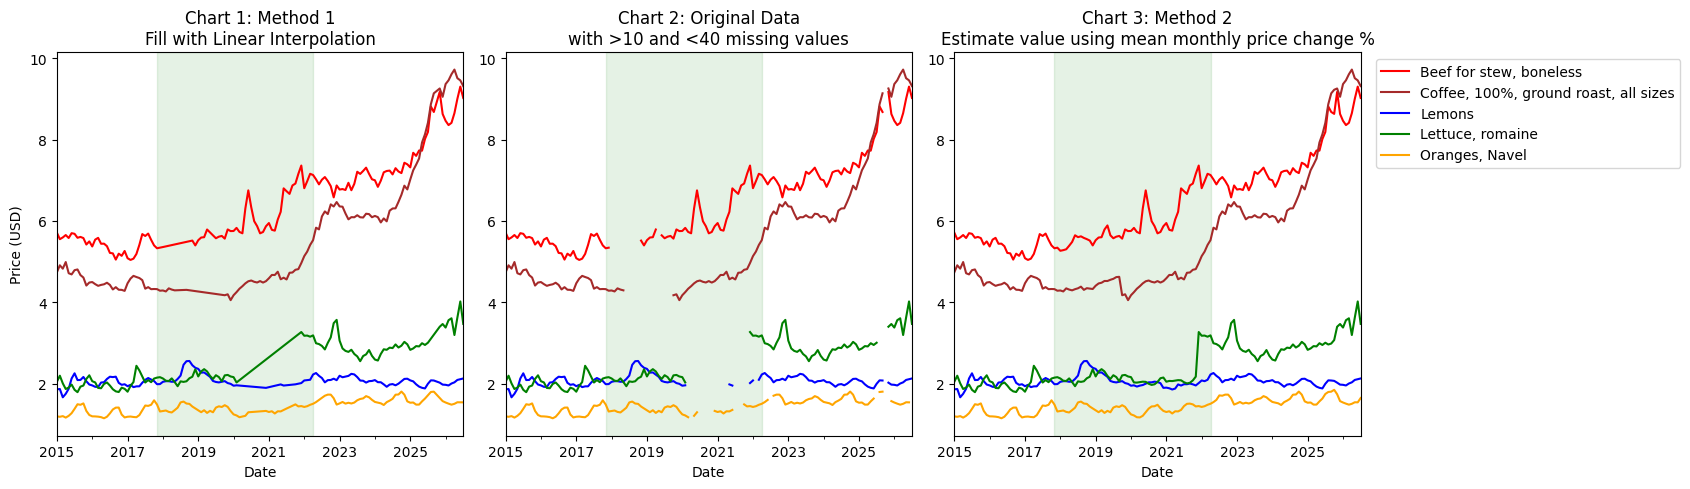

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

df_method_1[group_b].set_index('date').plot(ax = axes[0], legend = False, title="Chart 1: Method 1\nFill with Linear Interpolation", xlabel = 'Date', ylabel = 'Price (USD)', color = colors_2)
df_cleaning_2[group_b].set_index('date').plot(ax = axes[1], legend = False, title="Chart 2: Original Data\nwith >10 and <40 missing values", xlabel = 'Date', color = colors_2)
df_method_2[group_b].set_index('date').plot(ax = axes[2], legend = False, title= "Chart 3: Method 2\nEstimate value using mean monthly price change %", xlabel = 'Date', color = colors_2)

axes[2].legend(bbox_to_anchor=(1.02, 1))

axes[0].axvspan('2017-11-01', '2022-04-01', color='green', alpha=0.10)
axes[1].axvspan('2017-11-01', '2022-04-01', color='green', alpha=0.10)
axes[2].axvspan('2017-11-01', '2022-04-01', color='green', alpha=0.10)

fig.tight_layout()

We decided to use method 2 for all categories except for "Lettuce, romaine".

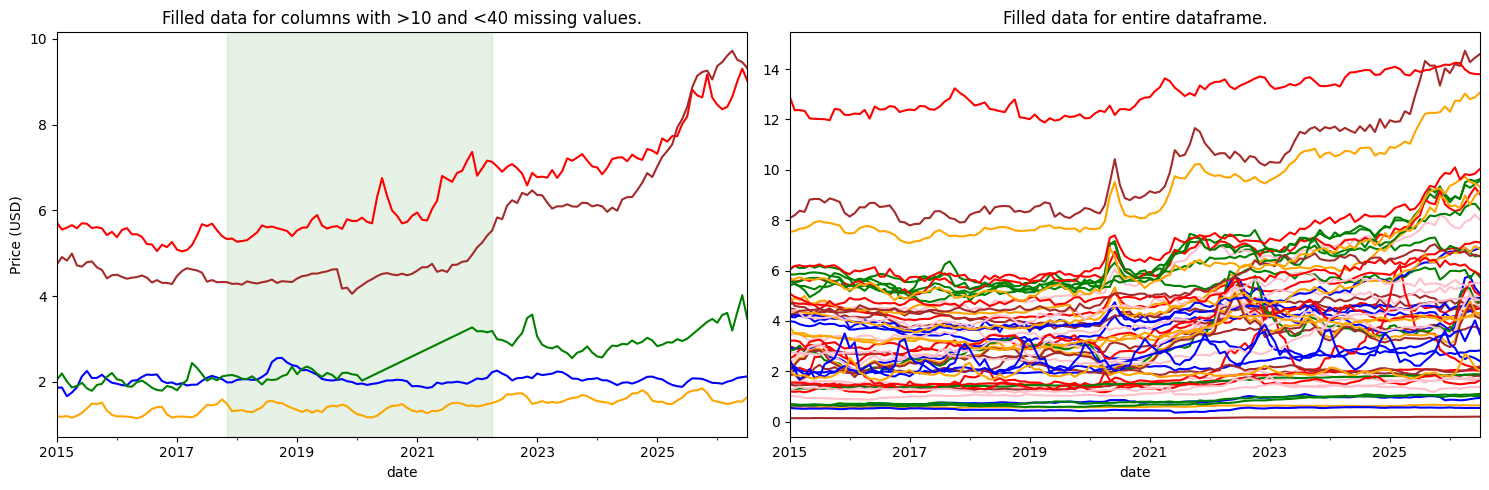

In [ ]:
df_cleaned = df_method_2.copy()
df_cleaned['Lettuce, romaine'] = df_method_1['Lettuce, romaine']
fig, axes = plt.subplots(1, 2, figsize = (15, 5))
axes_1 = df_cleaned[group_b].set_index('date').plot(legend = False,
                                                  color = colors_2,
                                                  ax = axes[0],
                                                  title = "Filled data for columns with >10 and <40 missing values.",
                                                  ylabel = 'Price (USD)')
axes_1.axvspan('2017-11-01', '2022-04-01', color='green', alpha=0.10)

df_cleaned.set_index('date').plot(legend = False,
                                                  color = colors_2,
                                                  ax = axes[1],
                                                  title = "Filled data for entire dataframe.")
#axes_1.legend(bbox_to_anchor=(1.02, 1))

plt.tight_layout()

In [ ]:
df_cleaned.tail(5)

,date,All Ham (Excluding Canned Ham and Luncheon Slices),All Other Pork (Excluding Canned Ham and Luncheon Slices),All Pork Chops,All Uncooked Beef Roasts,All Uncooked Beef Steaks,All Uncooked Other Beef (Excluding Veal),All uncooked ground beef,American processed cheese,Automotive diesel fuel,...,"Rice, white, long grain, uncooked","Round roast, USDA Choice, boneless",Spaghetti and macaroni,"Steak, round, USDA Choice, boneless","Steak, sirloin, USDA Choice, boneless","Strawberries, dry pint","Sugar, white, all sizes","Tomatoes, field grown",Utility (piped) gas,"Wine, red and white table, all sizes, any origin"
134,2026-03-01,4.439,3.628,4.181,8.857,12.732,7.675,6.863,4.783,4.919,...,1.060,8.477,1.308,9.610,14.124,2.582,0.996,2.255,1.688,14.236
135,2026-04-01,4.348,3.669,4.331,9.408,13.024,7.916,7.056,4.690,5.707,...,1.076,8.983,1.343,9.825,14.727,2.488,1.006,2.689,1.676,13.979
136,2026-05-01,4.448,3.755,4.389,9.286,12.802,8.013,7.064,4.572,5.780,...,1.071,8.615,1.374,9.789,14.274,2.595,1.034,2.489,1.677,13.841
137,2026-06-01,4.461,3.771,4.336,9.434,12.879,8.222,7.141,4.626,5.322,...,1.089,8.962,1.367,9.844,14.451,2.516,1.018,2.154,1.688,13.804
138,2026-07-01,4.489,3.671,4.244,9.571,13.064,8.009,7.116,4.746,5.077,...,1.100,9.155,1.381,10.036,14.592,2.404,1.024,2.003,1.704,13.794


##2.4: Feature Engineering  
The raw data only had 55 product names, so we grouped each one into a category using our own judgement. That lets us answer questions about food and energy as a whole, compare groups fairly, and use the same colours in every chart.

In [ ]:
# Commented out columns that are now dropped (contains >= 40 missing values)
# If you uncomment these, some cells further down may have errors.

item_info = {
    # Meat
    "All Ham (Excluding Canned Ham and Luncheon Slices)": "Meat",
    "All Other Pork (Excluding Canned Ham and Luncheon Slices)": "Meat",
    "All Pork Chops": "Meat",
    "All Uncooked Beef Roasts": "Meat",
    "All Uncooked Beef Steaks": "Meat",
    "All uncooked ground beef": "Meat",
    "All Uncooked Other Beef (Excluding Veal)": "Meat",
    "Bacon, sliced": "Meat",
    "Beef for stew, boneless": "Meat",
    "Chops, boneless": "Meat",
    "Chops, center cut, bone-in": "Meat",
    "Chuck roast, USDA Choice, boneless": "Meat",
    "Ground beef, 100% beef": "Meat",
    "Ground beef, lean and extra lean": "Meat",
    "Ground chuck, 100% beef": "Meat",
    "Ham, boneless, excluding canned": "Meat",
    "Round roast, USDA Choice, boneless": "Meat",
    "Steak, round, USDA Choice, boneless": "Meat",
    "Steak, sirloin, USDA Choice, boneless": "Meat",

    # Poultry
    "Chicken breast, boneless": "Poultry",
    "Chicken legs, bone-in": "Poultry",
    "Chicken, fresh, whole": "Poultry",

    # Dairy and fats
    "American processed cheese": "Dairy and fats",
    "Cheddar cheese, natural": "Dairy and fats",
    "Ice cream, prepackaged, bulk, regular": "Dairy and fats",
    "Milk, fresh, whole, fortified": "Dairy and fats",

    # Eggs
    "Eggs, grade A, large": "Eggs",

    # Bakery and grains
    "Bread, white, pan": "Bakery and grains",
    "Bread, whole wheat, pan": "Bakery and grains",
    "Cookies, chocolate chip": "Bakery and grains",
    "Flour, white, all purpose": "Bakery and grains",
    "Rice, white, long grain, uncooked": "Bakery and grains",
    "Spaghetti and macaroni": "Bakery and grains",

    # Fruit
    "Bananas": "Fruit",
    "Lemons": "Fruit",
    "Oranges, Navel": "Fruit",
    "Strawberries, dry pint": "Fruit",

    # Vegetables
    "Lettuce, romaine": "Vegetables",
    "Potatoes, white": "Vegetables",
    "Tomatoes, field grown": "Vegetables",

    # Drinks
    "Coffee, 100%, ground roast, all sizes": "Drinks",
    "Malt beverages, all types, all sizes, any origin": "Drinks",
    "Orange juice, frozen concentrate, 12 oz. can": "Drinks",
    "Wine, red and white table, all sizes, any origin": "Drinks",

    # Pantry staples and snacks
    "Beans, dried, any type, all sizes": "Pantry staples and snacks",
    "Potato chips": "Pantry staples and snacks",
    "Sugar, white, all sizes": "Pantry staples and snacks",

    # Energy
    "Automotive diesel fuel": "Energy",
    "Electricity": "Energy",
    "Fuel oil #2": "Energy",
    "Gasoline, all types": "Energy",
    "Gasoline, unleaded midgrade": "Energy",
    "Gasoline, unleaded premium": "Energy",
    "Gasoline, unleaded regular": "Energy",
    "Utility (piped) gas": "Energy",

    # "All soft drinks": "Drinks",  # column removed.
    # "All soft drinks, 12 pk, 12 oz., cans": "Drinks",  # column removed.
    # "Butter, stick": "Dairy and fats",  # column removed.
    # "Grapefruit": "Fruit",  # column removed.
    # "Lettuce, iceberg": "Vegetables",  # column removed.
    # "Milk, fresh, low-fat, reduced fat, skim": "Dairy and fats",  # column removed.
    # "Yogurt": "Dairy and fats"
}

data = df_cleaned.copy()   # never modify df_cleaned itself

if "date" in data.columns:
    data["date"] = pd.to_datetime(data["date"], errors="coerce")  # bad/missing -> NaT
    n_missing = data["date"].isna().sum()
    data = data.dropna(subset=["date"]).sort_values("date").set_index("date")
    print(f"Dropped {n_missing} rows with missing date")

assert isinstance(data.index, pd.DatetimeIndex), "Index is not dates, reload df_cleaned"
assert data.index.min().year >= 2015, "Index is broken (1970 dates), reload df_cleaned"



latest_date = data.index.max()
rows = []

for item in data.columns:
    prices = pd.to_numeric(data[item], errors="coerce").dropna()
    if prices.empty:
        continue
    rows.append({
        "item": item,
        "category": item_info.get(item, "unknown"),
        "first_date": prices.index.min().date(),
        "last_date": prices.index.max().date(),
        "first_price": round(prices.iloc[0], 3),
        "last_price": round(prices.iloc[-1], 3),
        "n_months": len(prices),
        "min_price": round(prices.min(), 3),
        "max_price": round(prices.max(), 3),
        "is_current": prices.index.max() == latest_date,
    })

summary = (
    pd.DataFrame(rows)
      .sort_values("item", key=lambda c: c.str.lower())
      .reset_index(drop=True)
)
summary

Dropped 0 rows with missing date


,item,category,first_date,last_date,first_price,last_price,n_months,min_price,max_price,is_current
0,All Ham (Excluding Canned Ham and Luncheon Sli...,Meat,2015-01-01,2026-07-01,3.211,4.489,139,2.822,4.710,True
1,All Other Pork (Excluding Canned Ham and Lunch...,Meat,2015-01-01,2026-07-01,2.991,3.671,139,2.516,3.846,True
2,All Pork Chops,Meat,2015-01-01,2026-07-01,3.988,4.244,139,3.186,4.452,True
3,All Uncooked Beef Roasts,Meat,2015-01-01,2026-07-01,5.838,9.571,139,5.109,9.571,True
4,All Uncooked Beef Steaks,Meat,2015-01-01,2026-07-01,7.530,13.064,139,7.094,13.064,True
5,All uncooked ground beef,Meat,2015-01-01,2026-07-01,4.675,7.116,139,4.029,7.141,True
6,All Uncooked Other Beef (Excluding Veal),Meat,2015-01-01,2026-07-01,4.734,8.009,139,4.406,8.222,True
7,American processed cheese,Dairy and fats,2015-01-01,2026-07-01,4.944,4.746,139,3.772,5.063,True
8,Automotive diesel fuel,Energy,2015-01-01,2026-07-01,2.964,5.077,139,2.040,5.780,True
9,"Bacon, sliced",Meat,2015-01-01,2026-07-01,5.589,6.584,139,4.940,7.608,True


# Step 3: Exploratory Data Analysis
How have U.S. grocery and energy prices changed between January 2015 and July 2026 — and which categories changed the most?”

### By what percentage did the price of each category increase between January 2015 and July 2026?

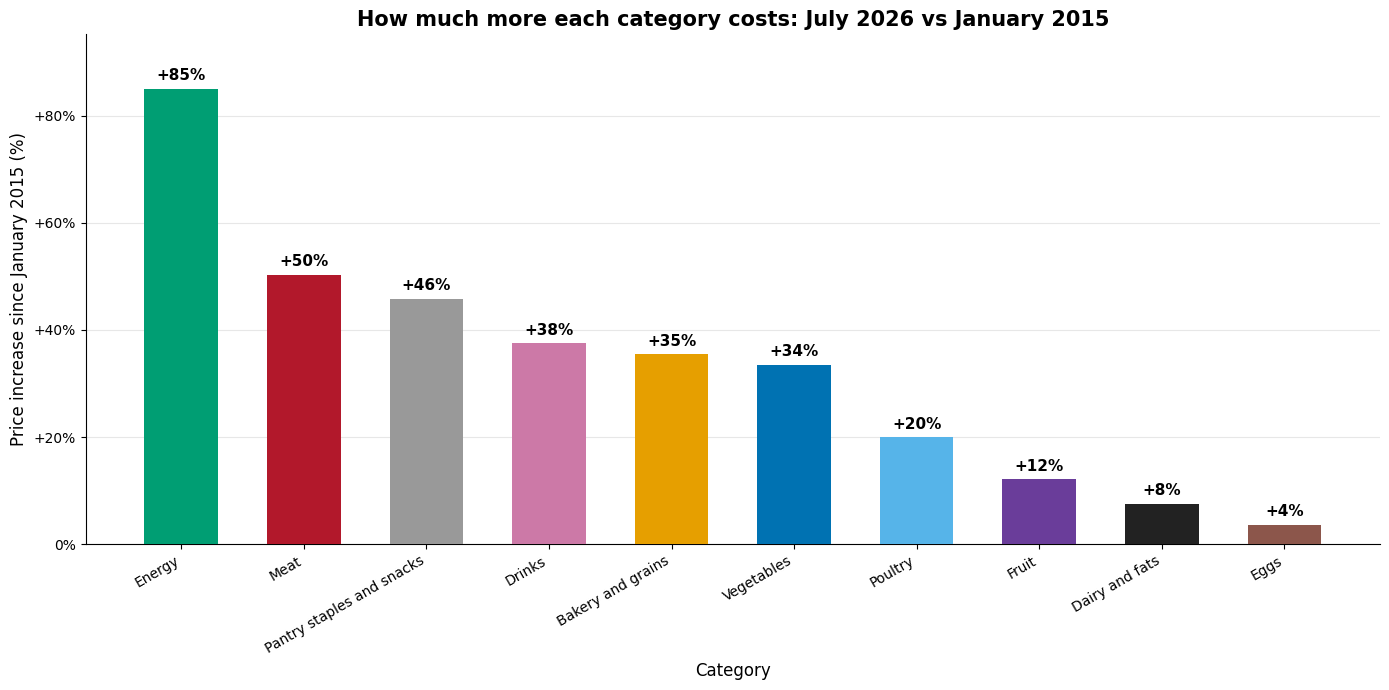

,Jan 2015 ($),Jul 2026 ($),Increase (%)
Energy,16.07,29.72,85.0
Meat,97.34,146.32,50.3
Pantry staples and snacks,6.36,9.27,45.8
Drinks,21.68,29.81,37.5
Bakery and grains,9.36,12.68,35.5
Vegetables,4.80,6.41,33.5
Poultry,6.57,7.88,20.0
Fruit,6.09,6.83,12.1
Dairy and fats,19.19,20.64,7.5
Eggs,2.11,2.19,3.6


In [ ]:
# Bar chart → Category growth as a percentage
# Naznin

CATEGORIES = {}
for item, cat in item_info.items():
    CATEGORIES.setdefault(cat, []).append(item)

# Same colour scheme as before (the line and pie charts also use CAT_COLOR)
COLORS = [
    "#B2182B",
    "#56B4E9",
    "#222222",
    "#8C564B",
    "#E69F00",
    "#6A3D9A",
    "#0072B2",
    "#CC79A7",
    "#999999",
    "#009E73"
]
CAT_COLOR = dict(zip(CATEGORIES, COLORS))

start = df_cleaned.index.min()
end = df_cleaned.index.max()

first = df_cleaned.loc[start]
last = df_cleaned.ffill().loc[end]

# only items that have a price on BOTH dates -> fair comparison
common = first.dropna().index.intersection(last.dropna().index)


def category_cost(prices):
    return pd.Series({
        category: prices[
            prices.index.intersection(items).intersection(common)
        ].sum()
        for category, items in CATEGORIES.items()
    })


cost_2015 = category_cost(first)
cost_2026 = category_cost(last)

# ---- convert to % increase since Jan 2015 ----
pct_change = ((cost_2026 / cost_2015 - 1) * 100).sort_values(ascending=False)
order = pct_change.index

x = np.arange(len(order))
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(x, pct_change, width=0.6, zorder=3,
              color=[CAT_COLOR[c] for c in order])  # each category keeps its colour

# label each bar: "+85%"
ax.bar_label(bars, labels=[f"+{p:.0f}%" for p in pct_change],
             padding=4, fontsize=11, fontweight="bold")

ax.set_title("How much more each category costs: July 2026 vs January 2015",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Category", fontsize=12)
ax.set_ylabel("Price increase since January 2015 (%)", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylim(0, pct_change.max() * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"+{v:.0f}%" if v > 0 else "0%"))

ax.grid(axis="y", alpha=0.3, zorder=0)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("4_bar_category_increase_2015_vs_2026.png", dpi=300, bbox_inches="tight")
plt.show()

# table of the values used in the chart
display(pd.DataFrame({
    "Jan 2015 ($)": cost_2015[order].round(2),
    "Jul 2026 ($)": cost_2026[order].round(2),
    "Increase (%)": pct_change.round(1),
}))


## Which categories of goods have gotten more expensive the fastest, relative to where they started?

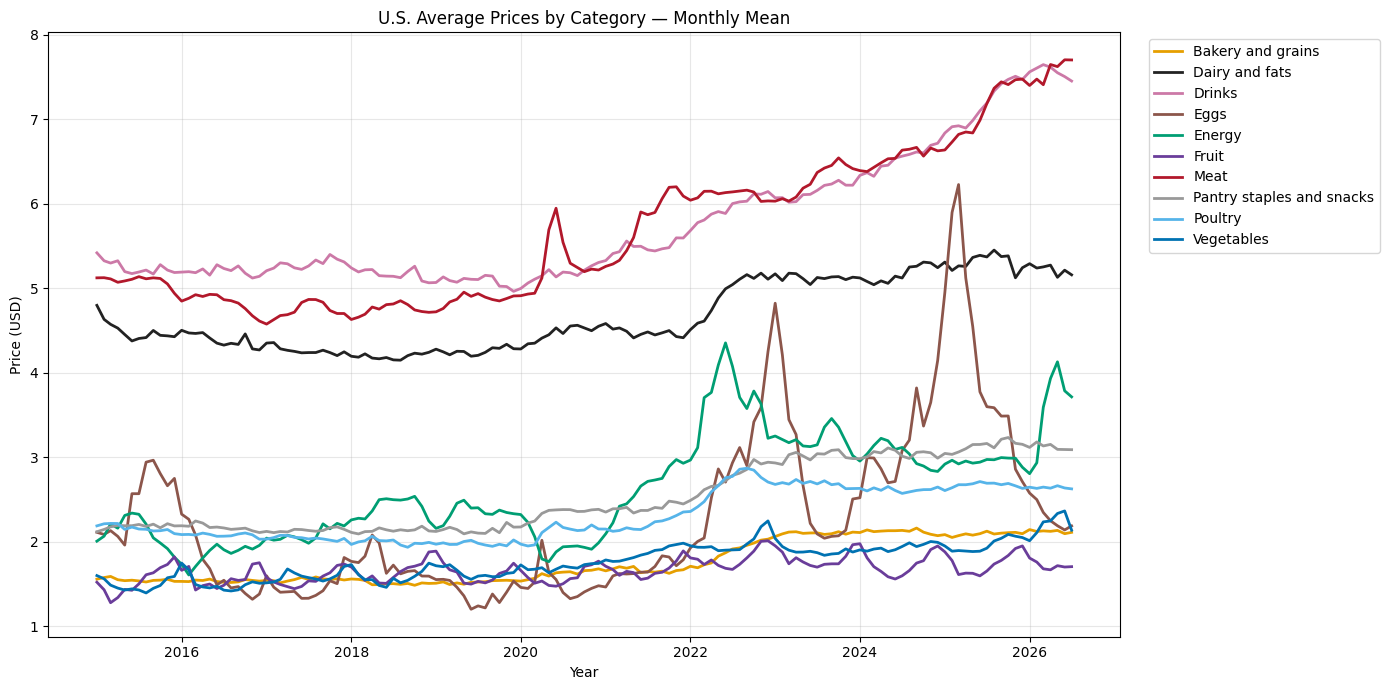


Mean Price Table


,date,Bakery and grains,Dairy and fats,Drinks,Eggs,Energy,Fruit,Meat,Pantry staples and snacks,Poultry,Vegetables
0,2015-01-01,1.56,4.80,5.42,2.11,2.01,1.52,5.12,2.12,2.19,1.60
1,2015-02-01,1.58,4.63,5.33,2.09,2.07,1.43,5.13,2.15,2.21,1.56
2,2015-03-01,1.59,4.57,5.30,2.13,2.21,1.28,5.11,2.18,2.22,1.49
3,2015-04-01,1.55,4.53,5.33,2.06,2.16,1.34,5.07,2.19,2.22,1.45
4,2015-05-01,1.54,4.45,5.20,1.96,2.31,1.44,5.09,2.19,2.15,1.43
...,...,...,...,...,...,...,...,...,...,...,...
134,2026-03-01,2.13,5.25,7.65,2.35,3.59,1.68,7.41,3.13,2.65,2.24
135,2026-04-01,2.12,5.27,7.62,2.25,3.93,1.67,7.65,3.15,2.64,2.25
136,2026-05-01,2.14,5.13,7.55,2.19,4.13,1.72,7.62,3.09,2.66,2.34
137,2026-06-01,2.10,5.21,7.50,2.14,3.79,1.70,7.70,3.09,2.64,2.37


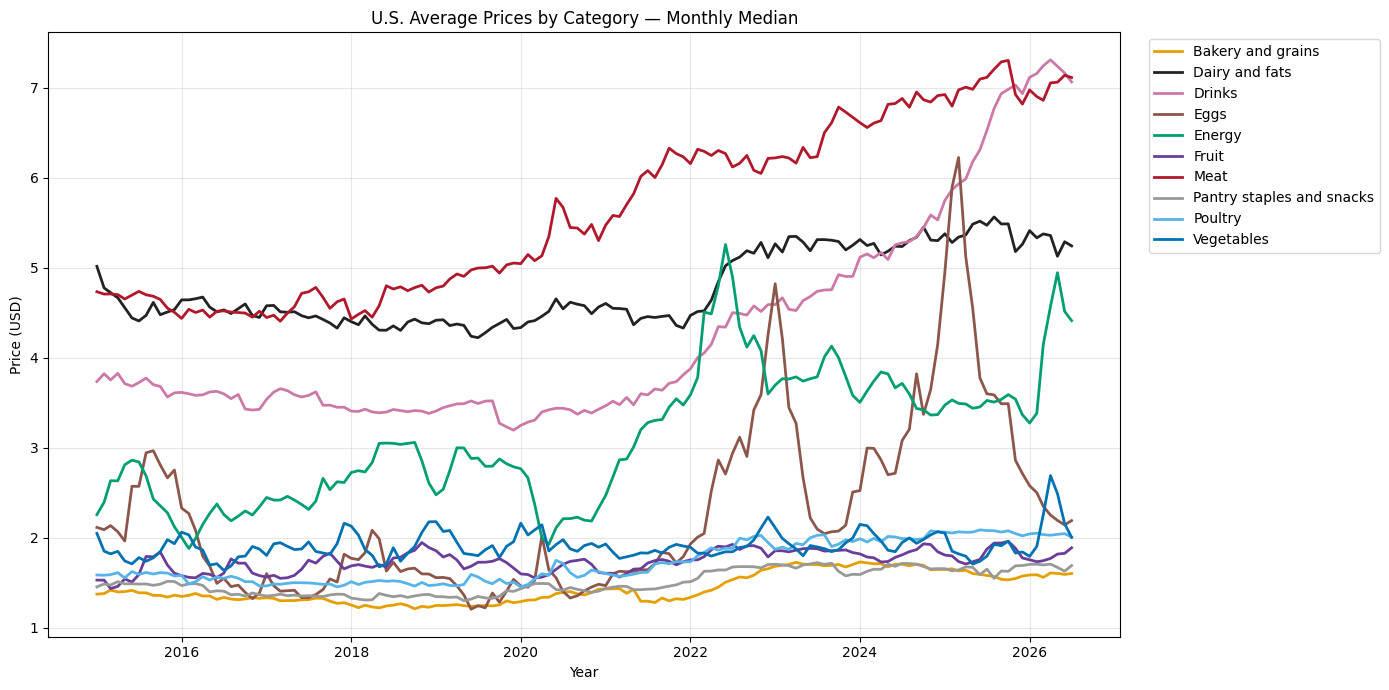


Median Price Table


,date,Bakery and grains,Dairy and fats,Drinks,Eggs,Energy,Fruit,Meat,Pantry staples and snacks,Poultry,Vegetables
0,2015-01-01,1.37,5.02,3.74,2.11,2.26,1.53,4.73,1.45,1.58,2.05
1,2015-02-01,1.38,4.78,3.82,2.09,2.39,1.53,4.71,1.48,1.58,1.85
2,2015-03-01,1.42,4.72,3.75,2.13,2.63,1.43,4.71,1.47,1.59,1.82
3,2015-04-01,1.40,4.67,3.83,2.06,2.63,1.46,4.70,1.51,1.61,1.85
4,2015-05-01,1.40,4.56,3.71,1.96,2.81,1.54,4.65,1.49,1.55,1.74
...,...,...,...,...,...,...,...,...,...,...,...
134,2026-03-01,1.56,5.38,7.25,2.35,4.15,1.74,6.86,1.70,2.03,2.26
135,2026-04-01,1.61,5.36,7.31,2.25,4.57,1.77,7.06,1.70,2.03,2.69
136,2026-05-01,1.60,5.13,7.24,2.19,4.95,1.82,7.06,1.67,2.04,2.49
137,2026-06-01,1.59,5.29,7.17,2.14,4.52,1.82,7.14,1.63,2.04,2.15


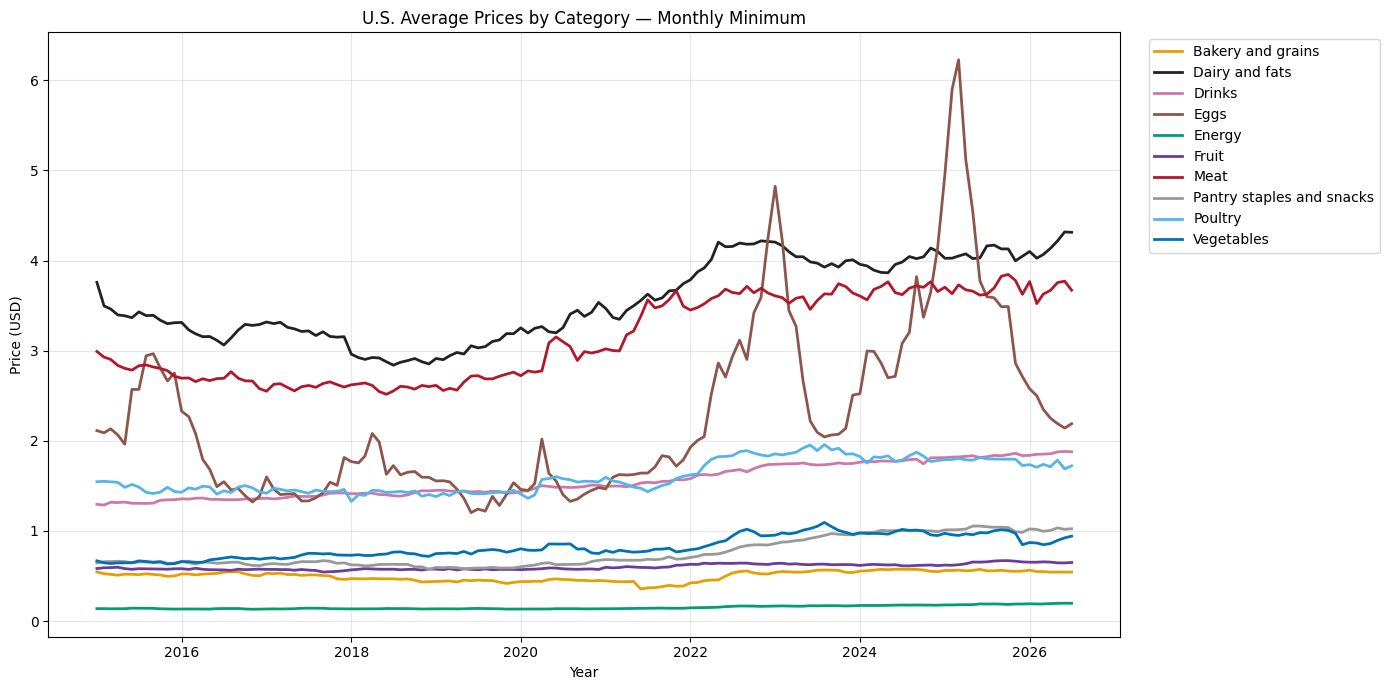


Minimum Price Table


,date,Bakery and grains,Dairy and fats,Drinks,Eggs,Energy,Fruit,Meat,Pantry staples and snacks,Poultry,Vegetables
0,2015-01-01,0.55,3.76,1.30,2.11,0.14,0.58,2.99,0.64,1.55,0.67
1,2015-02-01,0.52,3.50,1.29,2.09,0.14,0.59,2.93,0.66,1.55,0.65
2,2015-03-01,0.52,3.46,1.32,2.13,0.14,0.59,2.90,0.66,1.54,0.64
3,2015-04-01,0.51,3.40,1.32,2.06,0.14,0.60,2.84,0.66,1.54,0.64
4,2015-05-01,0.52,3.39,1.32,1.96,0.14,0.58,2.80,0.66,1.48,0.65
...,...,...,...,...,...,...,...,...,...,...,...
134,2026-03-01,0.55,4.07,1.85,2.35,0.19,0.66,3.63,1.00,1.74,0.85
135,2026-04-01,0.54,4.14,1.86,2.25,0.19,0.65,3.67,1.01,1.71,0.86
136,2026-05-01,0.54,4.22,1.88,2.19,0.20,0.65,3.76,1.03,1.79,0.89
137,2026-06-01,0.54,4.32,1.88,2.14,0.20,0.64,3.77,1.02,1.69,0.92


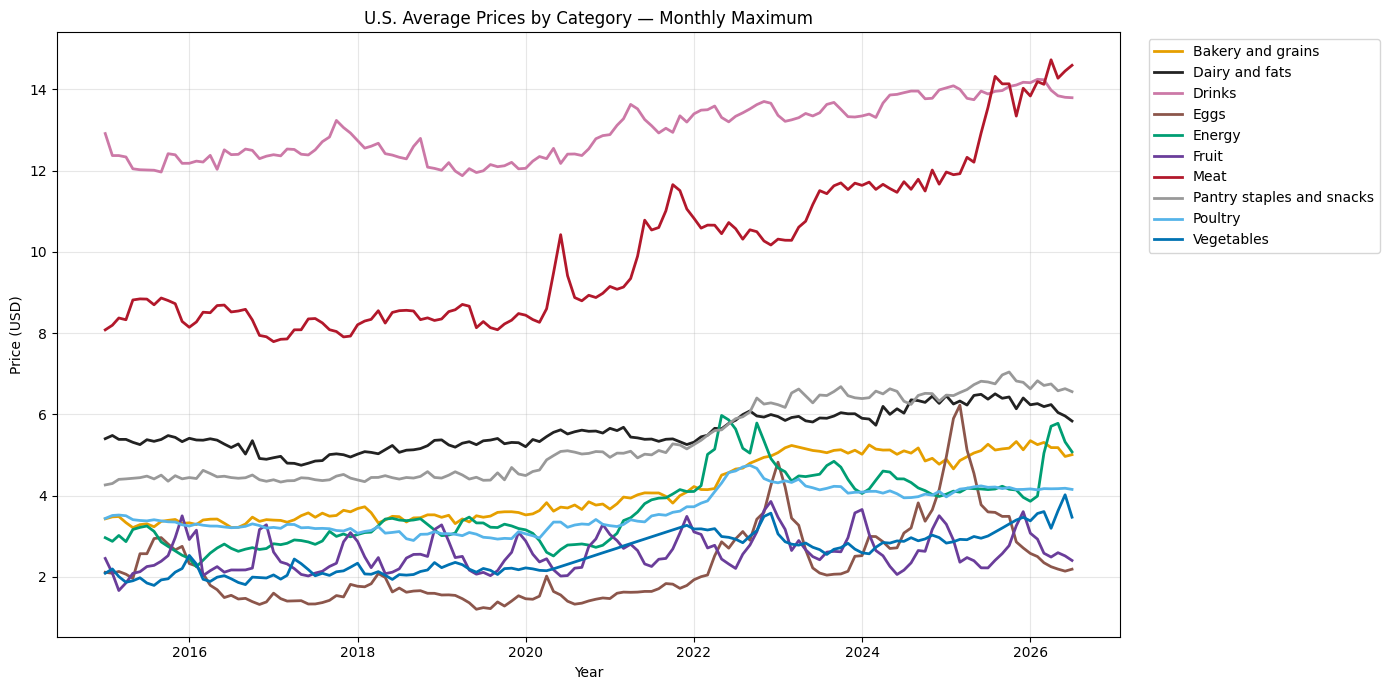


Maximum Price Table


,date,Bakery and grains,Dairy and fats,Drinks,Eggs,Energy,Fruit,Meat,Pantry staples and snacks,Poultry,Vegetables
0,2015-01-01,3.43,5.40,12.91,2.11,2.96,2.45,8.08,4.26,3.44,2.09
1,2015-02-01,3.48,5.48,12.37,2.09,2.88,2.09,8.19,4.30,3.51,2.19
2,2015-03-01,3.49,5.38,12.37,2.13,3.02,1.66,8.37,4.40,3.52,2.01
3,2015-04-01,3.34,5.38,12.34,2.06,2.87,1.85,8.33,4.41,3.50,1.87
4,2015-05-01,3.21,5.31,12.04,1.96,3.17,2.09,8.82,4.43,3.41,1.90
...,...,...,...,...,...,...,...,...,...,...,...
134,2026-03-01,5.31,6.19,14.24,2.35,5.04,2.58,14.12,6.71,4.17,3.61
135,2026-04-01,5.18,6.24,13.98,2.25,5.71,2.49,14.73,6.75,4.17,3.20
136,2026-05-01,5.18,6.04,13.84,2.19,5.78,2.60,14.27,6.58,4.17,3.62
137,2026-06-01,4.96,5.96,13.80,2.14,5.32,2.52,14.45,6.63,4.18,4.02


In [ ]:
# Line chart → Trend over time
# Nate

plot_df = df_cleaned.copy()

statistics = {
    "mean": "Mean",
    "median": "Median",
    "min": "Minimum",
    "max": "Maximum"
}

categories = sorted(set(item_info.values()))

for stat, title in statistics.items():

    # Table to store calculated values
    category_table = pd.DataFrame()
    category_table["date"] = plot_df["date"]

    plt.figure(figsize=(14, 7))

    for category in categories:

        # Get all items belonging to this category
        items = [
            item for item, cat in item_info.items()
            if cat == category
        ]

        # Calculate category statistic for each month
        category_data = plot_df[items].agg(stat, axis=1)

        # Save calculated values into table
        category_table[category] = category_data

        # Plot line
        plt.plot(
            plot_df["date"],
            category_data,
            label=category,
            color=CAT_COLOR[category],
            linewidth=2
        )

    plt.title(f"U.S. Average Prices by Category — Monthly {title}")
    plt.xlabel("Year")
    plt.ylabel("Price (USD)")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Display calculated values used in the chart
    print(f"\n{title} Price Table")
    display(category_table.round(2))

    # Save calculated table as CSV
    category_table.to_csv(
        f"us_average_prices_category_{stat}.csv",
        index=False
    )

## How much did the average price of each category change from one year to the next, and in which years did prices rise or fall the most?

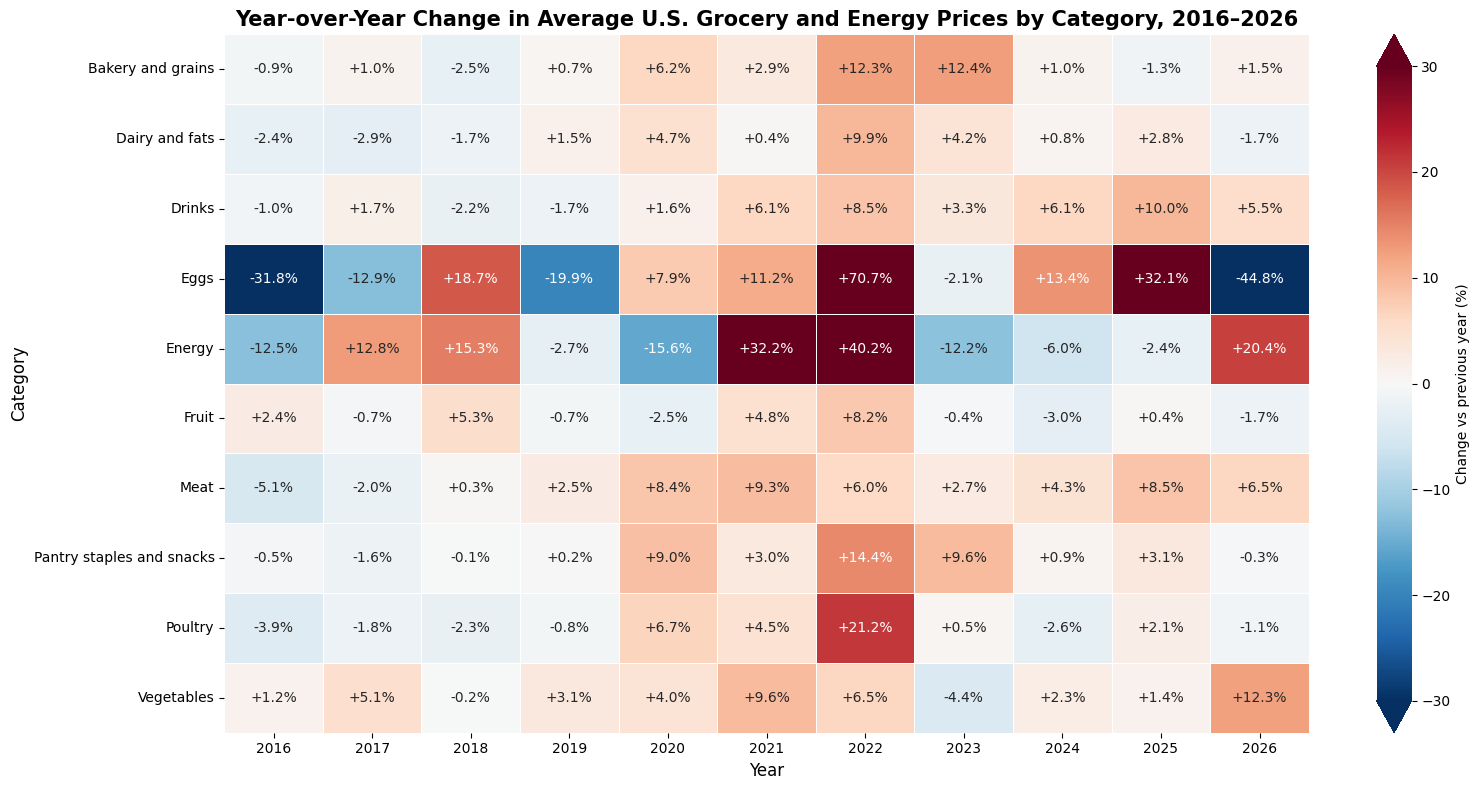

In [ ]:
# Prasanna  →  % change in average price by Category, year over year

heatmap_df = df_cleaned.copy()
heatmap_df['date'] = pd.to_datetime(heatmap_df['date'])
heatmap_df['Year'] = heatmap_df['date'].dt.year

price_columns = [
    col for col in heatmap_df.columns
    if col not in ['date', 'Year']
]

df_long = heatmap_df.melt(
    id_vars=['date', 'Year'],
    value_vars=price_columns,
    var_name='Product',
    value_name='Price'
)
df_long = df_long.dropna(subset=['Price'])

df_long['Category'] = df_long['Product'].map(item_info)
df_long = df_long.dropna(subset=['Category'])

category_year = (
    df_long
    .groupby(['Year', 'Category'])['Price']
    .mean()
    .reset_index()
)

heatmap_data = category_year.pivot(
    index='Category',
    columns='Year',
    values='Price'
)

# ---- NEW: year-over-year % change ----
pct_data = heatmap_data.pct_change(axis=1) * 100   # compare each year with the year before
pct_data = pct_data.drop(columns=pct_data.columns[0])  # 2015 has no previous year

# text inside each cell: "+5.2%" or "-3.1%"
labels = pct_data.map(lambda v: f"{v:+.1f}%")

# colour scale centred on 0 so red = increase, blue = decrease, white = no change
# capped at +/-30% so Eggs' extreme swings (+71%, -45%) don't wash out the other rows
# (cells beyond 30% just get the darkest colour; the printed number stays exact)
limit = 30

plt.figure(figsize=(16, 8))

sns.heatmap(
    pct_data,
    annot=labels,
    fmt='',
    cmap='RdBu_r',
    center=0,
    vmin=-limit,
    vmax=limit,
    linewidths=0.5,
    cbar_kws={'label': 'Change vs previous year (%)', 'extend': 'both'}
)

plt.title(
    'Year-over-Year Change in Average U.S. Grocery and Energy Prices by Category, 2016–2026',
    fontsize=15,
    fontweight='bold'
)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Category', fontsize=12)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    'heatmap_category_pct_change_2016_2026.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


## How many of our 55 items got more expensive, and by how much?

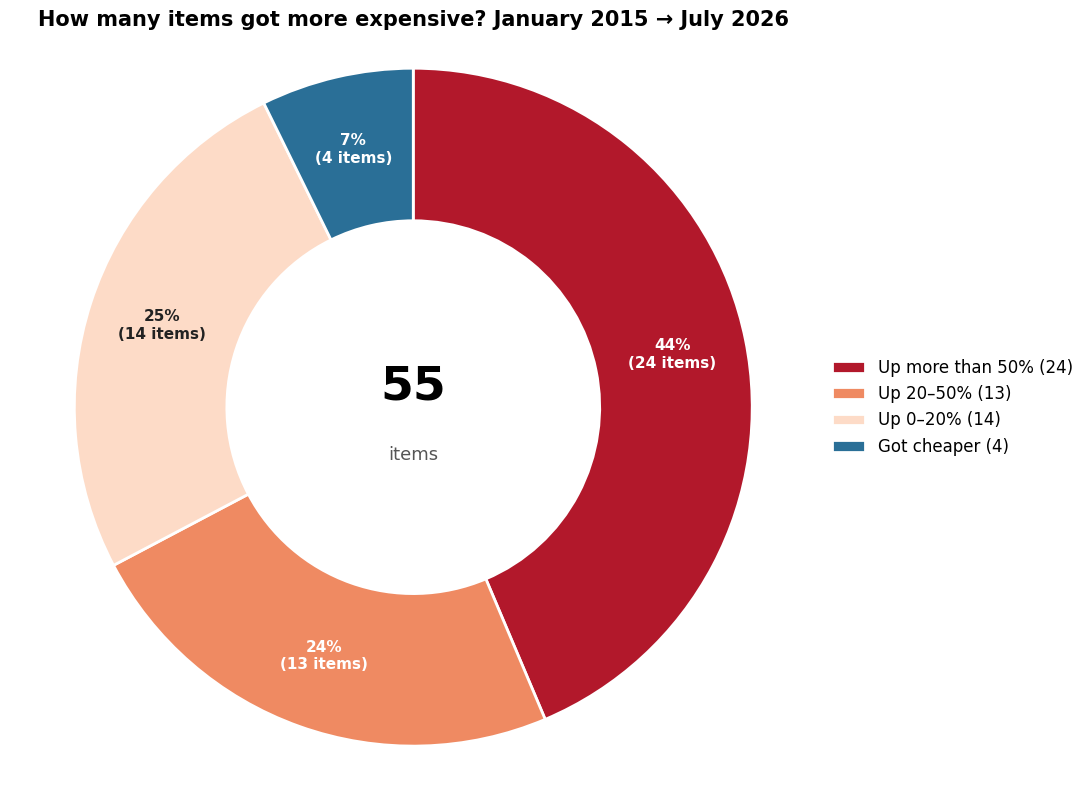

In [ ]:
# Pie chart → Distribution
# Mohamed
pie_df = summary.copy()
pie_df["pct_change"] = (pie_df["last_price"] / pie_df["first_price"] - 1) * 100

# put every item into one of 4 groups
groups = ["Up more than 50%", "Up 20–50%", "Up 0–20%", "Got cheaper"]
pie_df["group"] = pd.cut(pie_df["pct_change"],
                         bins=[-np.inf, 0, 20, 50, np.inf],
                         labels=groups[::-1], right=False)
counts = pie_df["group"].value_counts().reindex(groups)

# colours: darker red = bigger increase, blue = price fell
colors = ["#B2182B", "#EF8A62", "#FDDBC7", "#2A6F97"]

fig, ax = plt.subplots(figsize=(11, 8))
wedges, _, autotexts = ax.pie(
    counts,
    colors=colors,
    startangle=90,
    counterclock=False,
    autopct=lambda p: f"{p:.0f}%\n({round(p * counts.sum() / 100)} items)",
    pctdistance=0.78,
    wedgeprops={"width": 0.45, "edgecolor": "white", "linewidth": 2},   # donut
    textprops={"fontsize": 11},
)
# white text on the dark slices, dark text on the light slice
for t, c in zip(autotexts, colors):
    t.set_color("#222222" if c == "#FDDBC7" else "white")
    t.set_fontweight("bold")

# total in the middle of the donut
ax.text(0, 0.06, f"{counts.sum()}", ha="center", va="center", fontsize=34, fontweight="bold")
ax.text(0, -0.14, "items", ha="center", va="center", fontsize=13, color="#555555")

ax.legend(wedges, [f"{g} ({n})" for g, n in counts.items()],
          loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=12)
ax.set_title("How many items got more expensive? January 2015 → July 2026",
             fontsize=15, fontweight="bold")
ax.axis("equal")

plt.tight_layout()
plt.savefig("pie_item_outcomes_2015_2026.png", dpi=300, bbox_inches="tight")
plt.show()

## did every item in a category rise by a similar amount, or was the increase driven by just a few items?

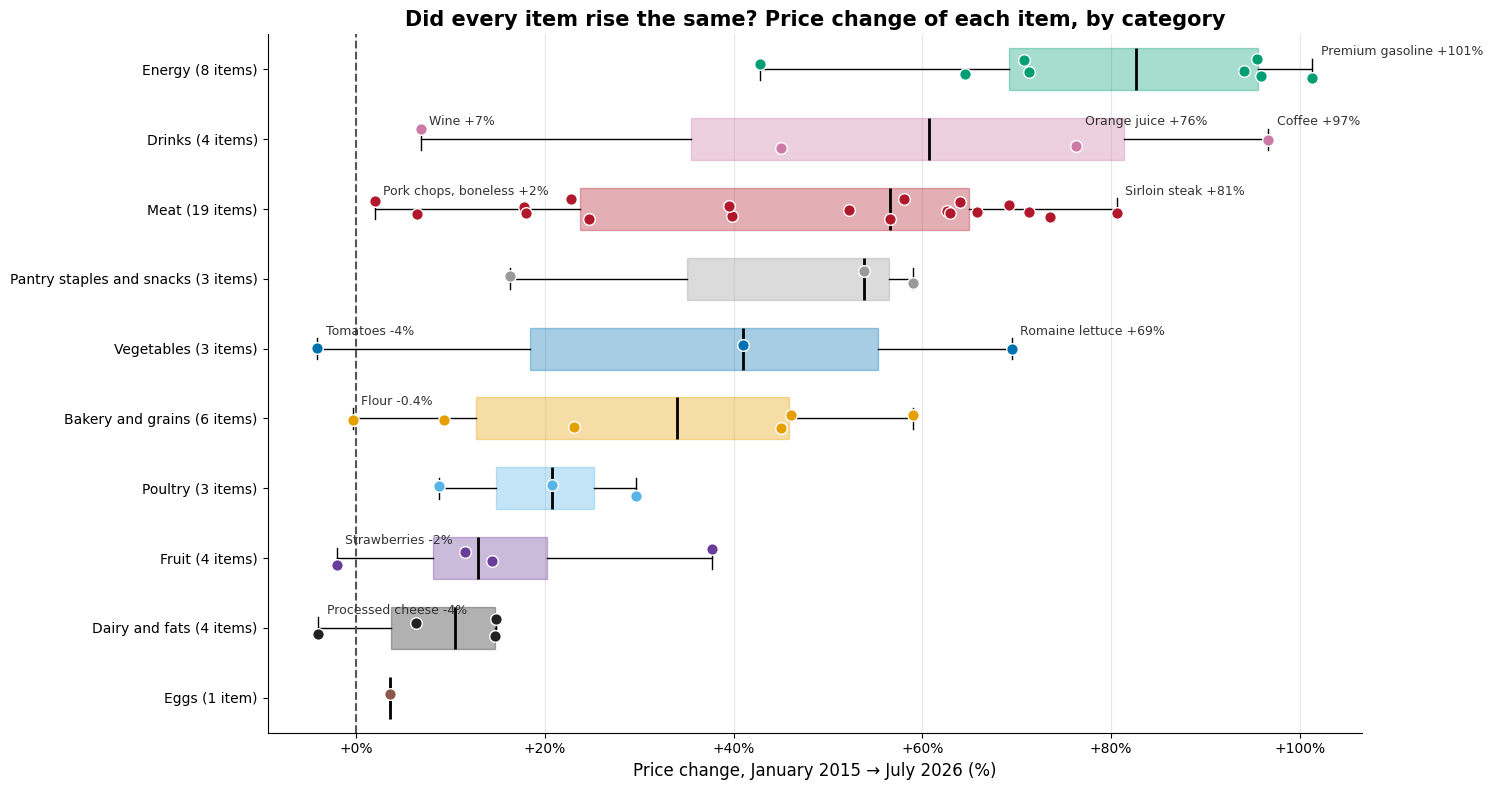

In [ ]:
# Million  →  Box plot: % price change of every item, grouped by category

box_df = summary.copy()
box_df["pct_change"] = (box_df["last_price"] / box_df["first_price"] - 1) * 100

# categories ordered by their median change (fastest-rising first)
order = (box_df.groupby("category")["pct_change"]
               .median()
               .sort_values(ascending=False)
               .index.tolist())
data = [box_df.loc[box_df["category"] == c, "pct_change"] for c in order]

fig, ax = plt.subplots(figsize=(15, 8))

# 1) the boxes (one per category, same colours as the other charts)
bp = ax.boxplot(data, vert=False, patch_artist=True, widths=0.6,
                showfliers=False,                     # dots below show every item anyway
                medianprops=dict(color="black", linewidth=2))
for box, cat in zip(bp["boxes"], order):
    box.set_facecolor(CAT_COLOR[cat])
    box.set_alpha(0.35)
    box.set_edgecolor(CAT_COLOR[cat])

# 2) every item as a dot, so small categories (Eggs = 1 item) are still visible
rng = np.random.default_rng(0)
for i, (cat, values) in enumerate(zip(order, data), start=1):
    y = i + rng.uniform(-0.15, 0.15, len(values))
    ax.scatter(values, y, color=CAT_COLOR[cat], edgecolor="white",
               s=70, zorder=3)

# 3) label the extreme items that tell the story
highlight = {
    "Gasoline, unleaded premium": "Premium gasoline",
    "Coffee, 100%, ground roast, all sizes": "Coffee",
    "Wine, red and white table, all sizes, any origin": "Wine",
    "Steak, sirloin, USDA Choice, boneless": "Sirloin steak",
    "Chops, boneless": "Pork chops, boneless",
    "Orange juice, frozen concentrate, 12 oz. can": "Orange juice",
    "Strawberries, dry pint": "Strawberries",
    "Tomatoes, field grown": "Tomatoes",
    "Lettuce, romaine": "Romaine lettuce",
    "American processed cheese": "Processed cheese",
    "Flour, white, all purpose": "Flour",
}
for _, row in box_df[box_df["item"].isin(highlight)].iterrows():
    y = order.index(row["category"]) + 1
    v = row["pct_change"]
    ax.annotate(f'{highlight[row["item"]]} {v:+.1f}%' if abs(v) < 1 else f'{highlight[row["item"]]} {v:+.0f}%',
                xy=(row["pct_change"], y), xytext=(6, 10),
                textcoords="offset points", fontsize=9, color="#333333")

# 0% line: left of it = the item got cheaper
ax.axvline(0, color="#555555", linestyle="--", linewidth=1.5)

ax.set_yticks(range(1, len(order) + 1))
ax.set_yticklabels([f"{c} ({len(d)} item{'s' if len(d) > 1 else ''})" for c, d in zip(order, data)])
ax.invert_yaxis()                                  # fastest-rising category on top
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0f}%"))
ax.set_xlabel("Price change, January 2015 → July 2026 (%)", fontsize=12)
ax.set_title("Did every item rise the same? Price change of each item, by category",
             fontsize=15, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("boxplot_item_pct_change_2015_2026.png", dpi=300, bbox_inches="tight")
plt.show()



In [ ]:
# Lamia
# Export dataset feature

df_cleaned.to_csv("cleaned_us_prices.csv", index=False)
print("Dataset exported successfully!")

Dataset exported successfully!


# DashBoard

In [ ]:
!pip install dash pandas_datareader -q

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pandas_datareader.data as web
from dash import Dash, dcc, html, Input, Output, State
from google.colab import output

# =========================
# DATA
# =========================
df = df_cleaned.loc[:, ~df_cleaned.columns.str.contains("^Unnamed")].copy()
df["date"] = pd.to_datetime(df["date"])
items = [i for i in item_info if i in df.columns]

long_df = (df.melt("date", items, "item", "price").dropna(subset=["price"])
             .sort_values(["item", "date"]).reset_index(drop=True))
long_df["category"] = long_df["item"].map(item_info)
long_df["year"] = long_df["date"].dt.year
g = long_df.groupby("item")["price"]
long_df["rolling_12mo"] = g.transform(lambda x: x.rolling(12, min_periods=12).mean())
long_df["yoy_pct"] = g.pct_change(12, fill_method=None) * 100      # same month, previous year

# CPI (fetched 13 months early so the first year has a YoY value too)
cpi = web.DataReader("CPIAUCSL", "fred", df["date"].min() - pd.DateOffset(months=13), df["date"].max()).reset_index()
cpi.columns = ["date", "cpi"]
cpi["year"] = cpi["date"].dt.year
cpi["yoy_pct"] = cpi["cpi"].pct_change(12, fill_method=None) * 100
cpi_yoy = cpi.set_index("date")["yoy_pct"]

CATS = sorted(long_df["category"].dropna().unique())
YMIN, YMAX = int(long_df["year"].min()), int(long_df["year"].max())
COLORS = globals().get("CAT_COLOR", {})
FIGS = ["hero", "bar", "pie", "box", "yoy", "heat"]

GROUPS = ["Up more than 50%", "Up 20–50%", "Up 0–20%", "Got cheaper"]          # pie slices, clockwise
G_COLORS = dict(zip(GROUPS, ["#B2182B", "#EF8A62", "#FDDBC7", "#2A6F97"]))
G_TEXT = ["white", "white", "#222222", "white"]


# =========================
# HELPERS
# =========================
def subset(mode, years, cats, sel):
    d = long_df[long_df["year"].between(*years) & long_df["category"].isin(cats or [])]
    return d[d["item"].isin(sel or [])] if mode == "item" else d


def first_last(d, n=12):
    """% change between the 12-month AVERAGES at each end of the range (cancels seasonality)."""
    s = d.sort_values("date").groupby("item")["price"]
    out = s.agg(first=lambda x: x.head(n).mean(), last=lambda x: x.tail(n).mean())
    out["pct"] = (out["last"] / out["first"] - 1) * 100
    out["category"] = out.index.map(item_info)
    return out


def fmt(fig, title, h=380, **kw):
    fig.update_layout(template="plotly_white", title=title, height=h, margin=dict(l=50, r=30, t=60, b=40), **kw)
    return fig


def blank(msg):
    return fmt(go.Figure(), msg)


def pct(x):
    return "n/a" if pd.isna(x) else f"{x:+.1f}%"


def kpi(title, value, sub=""):
    return html.Div([html.Div(title, style={"fontSize": "13px", "color": "#555"}),
                     html.Div(value, style={"fontSize": "26px", "fontWeight": "700", "color": "#2a6f97"}),
                     html.Div(sub, style={"fontSize": "12px", "color": "#888"})],
                    style={**BOX, "flex": "1", "minWidth": "180px", "padding": "14px 18px"})


def card(gid, **style):
    return html.Div(dcc.Graph(id=gid, config={"displayModeBar": False}), style={**BOX, "padding": "6px", **style})


def field(label, child, flex="1", **kw):
    return html.Div([html.Label(label, style={"fontWeight": "600", "fontSize": "13px"}), child],
                    style={"flex": flex, "minWidth": "220px"}, **kw)


# =========================
# LAYOUT
# =========================
BOX = {"background": "white", "borderRadius": "10px", "boxShadow": "0 1px 4px rgba(0,0,0,.12)"}
app = Dash(__name__)

app.layout = html.Div(style={"maxWidth": "1400px", "margin": "auto", "padding": "18px", "fontFamily": "Helvetica",
                             "background": "#f4f6f8"}, children=[
    html.H2("U.S. Consumer Price Trends", style={"margin": "0 0 4px"}),
    html.Div("Category Overview: median price trend per category.  Item Detail: drill into individual items "
             "from the selected categories.  Everything is compared with general inflation (CPI).",
             style={"color": "#666", "fontSize": "13px", "marginBottom": "12px"}),

    html.Div(style={**BOX, "display": "flex", "gap": "18px", "flexWrap": "wrap", "alignItems": "flex-end",
                    "padding": "12px 16px", "marginBottom": "14px"}, children=[
        field("View", dcc.RadioItems(id="mode", value="category", inline=True, inputStyle={"marginLeft": "10px"},
              options=[{"label": " Category Overview", "value": "category"}, {"label": " Item Detail", "value": "item"}])),
        field("Years", dcc.RangeSlider(id="years", min=YMIN, max=YMAX, step=1, value=[YMIN, YMAX],
              marks={y: f"'{str(y)[2:]}" for y in range(YMIN, YMAX + 1)}), "2"),
        field("Categories", dcc.Dropdown(id="cats", options=CATS, value=CATS[:4], multi=True), "2"),
        field("Items", dcc.Dropdown(id="items", multi=True, placeholder="Select items"), "2", id="item-box"),
        html.Div([html.Button("⬇ CSV", id="btn", style={"padding": "9px 14px", "background": "#2a6f97", "color": "white",
                                                        "border": "none", "borderRadius": "6px", "cursor": "pointer"}),
                  dcc.Download(id="download")]),
    ]),

    html.Div(id="kpis", style={"display": "flex", "gap": "14px", "flexWrap": "wrap", "marginBottom": "14px"}),
    card("hero", marginBottom="14px"),
    html.Div(style={"display": "grid", "gridTemplateColumns": "repeat(auto-fit, minmax(480px, 1fr))", "gap": "14px"},
             children=[card("bar"), card("pie"), card("box"), card("yoy"), card("heat", gridColumn="1 / -1")]),
])


# =========================
# CALLBACKS
# =========================
@app.callback(Output("items", "options"), Output("items", "value"), Input("cats", "value"), State("items", "value"))
def sync_items(cats, cur):
    its = sorted(long_df.loc[long_df["category"].isin(cats or []), "item"].unique())
    keep = [i for i in (cur or []) if i in its] or its[:1]
    return [{"label": f"{item_info[i]} — {i}", "value": i} for i in its], keep


@app.callback(Output("item-box", "style"), Output("kpis", "children"), *[Output(f, "figure") for f in FIGS],
              Input("mode", "value"), Input("years", "value"), Input("cats", "value"), Input("items", "value"))
def update(mode, years, cats, sel):
    y0, y1 = years
    by = "category" if mode == "category" else "item"
    show = {"flex": "2", "minWidth": "220px", "display": "block" if by == "item" else "none"}
    d = subset(mode, years, cats, sel)
    if d.empty:
        return show, [], *([blank(f"Select at least one {by}")] * 6)

    cmap = COLORS if by == "category" else None
    fl = first_last(d)
    cw = cpi[cpi["year"].between(y0, y1)]
    cpi_pct = (cw["cpi"].tail(12).mean() / cw["cpi"].head(12).mean() - 1) * 100
    cpi_year = cw.groupby("year")["yoy_pct"].mean()
    last_m = d["date"].max()
    yoy_now = d.loc[d["date"] == last_m, "yoy_pct"].median()

    # KPIs
    kpis = [kpi("Items tracked", str(len(fl)), f"{d['category'].nunique()} categories"),
            kpi("Median price change", pct(fl["pct"].median()), f"12-mo avg vs 12-mo avg · CPI {pct(cpi_pct)}"),
            kpi("Latest YoY", pct(yoy_now), f"{last_m:%b %Y} · CPI {pct(cpi_yoy.asof(last_m))}"),
            kpi("Beating inflation", f"{(fl['pct'] > cpi_pct).mean() * 100:.0f}%", "of items rose faster than CPI")]

    # Hero: rebased 12-mo rolling average vs general inflation
    h = (d.dropna(subset=["rolling_12mo"]).sort_values("date")
          .groupby(["date", by], as_index=False)["rolling_12mo"].median())
    h["index"] = h["rolling_12mo"] / h.groupby(by)["rolling_12mo"].transform("first") * 100
    hero = px.line(h, x="date", y="index", color=by, color_discrete_map=cmap, labels={"date": "", "index": "Price Index"})
    hero.update_traces(line_width=2.5)
    end = cw["cpi"].iloc[-1] / cw["cpi"].iloc[0] * 100
    hero.add_scatter(x=[cw["date"].iloc[0], cw["date"].iloc[-1]], y=[100, end], mode="lines+markers",
                     line=dict(color="#1d3557", width=3, dash="dot"), name=f"General Inflation ({end - 100:+.1f}%)")
    hero.add_hline(y=100, line_dash="dash", line_color="#888", annotation_text="Baseline = 100")

    # Bar: change between 12-month averages, coloured by above / below CPI
    b = (fl.groupby("category")["pct"].median() if by == "category" else fl["pct"]).sort_values(ascending=False)
    b = b.rename("pct").reset_index()
    b["vs CPI"] = np.where(b["pct"] > cpi_pct, "Above CPI", "Below CPI")
    bar = px.bar(b, x=by, y="pct", color="vs CPI", labels={"pct": "Change (%)", by: ""},
                 color_discrete_map={"Above CPI": "#B2182B", "Below CPI": "#2A6F97"})
    bar.add_hline(y=cpi_pct, line_dash="dot", line_color="#1d3557", annotation_text=f"CPI {pct(cpi_pct)}")

    # Pie: how many items fell in each price-change group
    fl["group"] = pd.cut(fl["pct"], [-np.inf, 0, 20, 50, np.inf], labels=GROUPS[::-1], right=False)
    n = fl["group"].value_counts().reindex(GROUPS)
    pie = px.pie(names=n.index, values=n.values, hole=0.5, color=n.index, color_discrete_map=G_COLORS)
    pie.update_traces(sort=False, direction="clockwise", textfont_color=G_TEXT, marker_line=dict(color="white", width=2),
                      texttemplate="%{percent:.0%}<br>(%{value} items)")
    pie.add_annotation(text=f"<b>{n.sum()}</b><br>items", showarrow=False, font_size=20)

    # Box: spread of monthly YoY %
    box = px.box(d.dropna(subset=["yoy_pct"]), x=by, y="yoy_pct", color=by, color_discrete_map=cmap,
                 labels={"yoy_pct": "YoY change (%)", by: ""})
    box.add_hline(y=cpi_year.mean(), line_dash="dot", line_color="#1d3557", annotation_text="CPI avg YoY")

    # YoY comparison by year vs CPI
    yy = d.groupby(["year", by])["yoy_pct"].median().reset_index()
    yoy = px.line(yy, x="year", y="yoy_pct", color=by, markers=True, color_discrete_map=cmap,
                  labels={"yoy_pct": "YoY change (%)", "year": ""})
    yoy.add_scatter(x=cpi_year.index, y=cpi_year.values, mode="lines+markers", name="CPI (all items)",
                    line=dict(color="#1d3557", width=3, dash="dot"))

    # Heatmap: median YoY % by year, CPI as the top row
    m = d.pivot_table(index=by, columns="year", values="yoy_pct", aggfunc="median")
    cpi_row = pd.DataFrame([cpi_year.reindex(m.columns).values], index=["CPI (all items)"], columns=m.columns)
    m = pd.concat([cpi_row, m])
    heat = px.imshow(m, text_auto=".1f", aspect="auto", color_continuous_scale="RdBu_r",
                     color_continuous_midpoint=0, labels={"color": "YoY %"})
    heat.update_xaxes(type="category")

    return (show, kpis,
            fmt(hero, f"{by.title()} Price Trends vs. General Inflation", 520, hovermode="x unified"),
            fmt(bar, f"Price change, 12-mo average → 12-mo average ({y0}–{y1})"),
            fmt(pie, f"How many items got more expensive? {y0} → {y1}"),
            fmt(box, "Spread of year-over-year price change"),
            fmt(yoy, "Median YoY change by year vs CPI", hovermode="x unified"),
            fmt(heat, "YoY price change by year (CPI in the top row)", max(380, 26 * len(m) + 110)))


@app.callback(Output("download", "data"), Input("btn", "n_clicks"), State("mode", "value"), State("years", "value"),
              State("cats", "value"), State("items", "value"), prevent_initial_call=True)
def export(_, mode, years, cats, sel):
    return dcc.send_data_frame(subset(mode, years, cats, sel).to_csv, f"price_trends_{years[0]}_{years[1]}.csv", index=False)


# =========================
# RUN
# =========================
PORT = 8060
print("Click the link below:")
output.serve_kernel_port_as_window(PORT)
app.run(host="0.0.0.0", port=PORT, jupyter_mode=None)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 61.3 MB/s eta 0:00:00
Click the link below:
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>